In [1]:
import os
import json
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score

c:\Users\David\Documents\4530\ACIT4530\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


# 1 Load Step 1 Results

We load the filtered interaction data and the pairwise datasets created in Step 1.

The interaction-level splits are retained for later individual and group ranking evaluation.  
The pairwise datasets are used in this step for BPR training and pairwise prediction evaluation.

In [3]:
data_dir = "./results_step1"

ratings_filtered = pd.read_parquet(f"{data_dir}/ratings_filtered.parquet")

train_df = pd.read_parquet(f"{data_dir}/train_split.parquet")
val_df = pd.read_parquet(f"{data_dir}/validation_split.parquet")
test_df = pd.read_parquet(f"{data_dir}/test_split.parquet")

train_pairs = pd.read_parquet(f"{data_dir}/train_pairs.parquet")
val_pairs = pd.read_parquet(f"{data_dir}/validation_pairs.parquet")
test_pairs = pd.read_parquet(f"{data_dir}/test_pairs.parquet")

### 1.1 Standardize Pairwise Column Names

Step 1 may save pairwise columns using either descriptive names:

- `preferred_item`
- `less_preferred_item`
- `rating_preferred`
- `rating_less_preferred`

or BPR-style names:

- `pos_item`
- `neg_item`
- `rating_pos`
- `rating_neg`

For Step 2, we standardize all pairwise datasets to the BPR-style names.

In [4]:
def standardize_pair_columns(pair_df):
    df = pair_df.copy()

    rename_map = {
        "preferred_item": "pos_item",
        "less_preferred_item": "neg_item",
        "rating_preferred": "rating_pos",
        "rating_less_preferred": "rating_neg",
        "timestamp_preferred": "timestamp_pos",
        "timestamp_less_preferred": "timestamp_neg",
    }

    active_rename_map = {
        old_name: new_name
        for old_name, new_name in rename_map.items()
        if old_name in df.columns
    }

    df = df.rename(columns=active_rename_map)

    required_columns = [
        "user_id",
        "pos_item",
        "neg_item",
        "rating_pos",
        "rating_neg",
        "rating_diff",
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required pairwise columns after standardization: {missing_columns}"
        )

    return df


train_pairs = standardize_pair_columns(train_pairs)
val_pairs = standardize_pair_columns(val_pairs)
test_pairs = standardize_pair_columns(test_pairs)

display(train_pairs.head())
print("Train pair columns:", train_pairs.columns.tolist())

,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg
0,1,1022,2340,5,3,2,978300055,978300103
1,1,1270,2340,5,3,2,978300055,978300103
2,1,1022,720,5,3,2,978300055,978300760
3,1,1270,720,5,3,2,978300055,978300760
4,1,1022,914,5,3,2,978300055,978301968


Train pair columns: ['user_id', 'pos_item', 'neg_item', 'rating_pos', 'rating_neg', 'rating_diff', 'timestamp_pos', 'timestamp_neg']


### 1.2 Load Summary

In [5]:
load_summary = pd.DataFrame([
    {
        "dataset": "ratings_filtered",
        "rows": len(ratings_filtered),
        "columns": ratings_filtered.shape[1],
    },
    {
        "dataset": "train_df",
        "rows": len(train_df),
        "columns": train_df.shape[1],
    },
    {
        "dataset": "val_df",
        "rows": len(val_df),
        "columns": val_df.shape[1],
    },
    {
        "dataset": "test_df",
        "rows": len(test_df),
        "columns": test_df.shape[1],
    },
    {
        "dataset": "train_pairs",
        "rows": len(train_pairs),
        "columns": train_pairs.shape[1],
    },
    {
        "dataset": "val_pairs",
        "rows": len(val_pairs),
        "columns": val_pairs.shape[1],
    },
    {
        "dataset": "test_pairs",
        "rows": len(test_pairs),
        "columns": test_pairs.shape[1],
    },
])

display(load_summary)

,dataset,rows,columns
0,ratings_filtered,960916,5
1,train_df,759509,5
2,val_df,100817,5
3,test_df,100590,5
4,train_pairs,5692244,8
5,val_pairs,478098,8
6,test_pairs,507550,8


### 1.3 Pairwise Sanity Checks

Before training, we verify that the loaded pairwise datasets are valid:

- all pairs satisfy the selected preference threshold;
- there are no semantic duplicate pairs;
- there are no reverse conflicts within the same split;
- validation and test users/items are known from the training pairwise data.

In [6]:
pair_min_diff = 2


def semantic_duplicate_count(pair_df):
    return pair_df.duplicated(["user_id", "pos_item", "neg_item"]).sum()


def reverse_conflict_count(pair_df):
    forward = set(
        zip(pair_df["user_id"], pair_df["pos_item"], pair_df["neg_item"])
    )

    reverse = set(
        zip(pair_df["user_id"], pair_df["neg_item"], pair_df["pos_item"])
    )

    return len(forward & reverse)


pair_quality_rows = []

for split_name, pair_df in [
    ("train", train_pairs),
    ("validation", val_pairs),
    ("test", test_pairs),
]:
    pair_quality_rows.append({
        "split": split_name,
        "pairs": len(pair_df),
        "users": pair_df["user_id"].nunique(),
        "items": len(
            set(pair_df["pos_item"].unique())
            | set(pair_df["neg_item"].unique())
        ),
        "min_rating_diff": pair_df["rating_diff"].min(),
        "all_rating_diff_ge_min": bool(
            pair_df["rating_diff"].ge(pair_min_diff).all()
        ),
        "semantic_duplicates": int(semantic_duplicate_count(pair_df)),
        "reverse_conflicts": int(reverse_conflict_count(pair_df)),
    })

pair_quality_summary = pd.DataFrame(pair_quality_rows)
display(pair_quality_summary)

assert pair_quality_summary["all_rating_diff_ge_min"].all()
assert pair_quality_summary["semantic_duplicates"].sum() == 0
assert pair_quality_summary["reverse_conflicts"].sum() == 0

,split,pairs,users,items,min_rating_diff,all_rating_diff_ge_min,semantic_duplicates,reverse_conflicts
0,train,5692244,4722,3250,2,True,0,0
1,validation,478098,4158,3193,2,True,0,0
2,test,507550,4164,3222,2,True,0,0


In [7]:
train_users_original = set(train_pairs["user_id"].unique())
train_items_original = (
    set(train_pairs["pos_item"].unique())
    | set(train_pairs["neg_item"].unique())
)

coverage_summary = pd.DataFrame([
    {
        "split": "validation",
        "unknown_users": len(
            set(val_pairs["user_id"].unique()) - train_users_original
        ),
        "unknown_pos_items": len(
            set(val_pairs["pos_item"].unique()) - train_items_original
        ),
        "unknown_neg_items": len(
            set(val_pairs["neg_item"].unique()) - train_items_original
        ),
    },
    {
        "split": "test",
        "unknown_users": len(
            set(test_pairs["user_id"].unique()) - train_users_original
        ),
        "unknown_pos_items": len(
            set(test_pairs["pos_item"].unique()) - train_items_original
        ),
        "unknown_neg_items": len(
            set(test_pairs["neg_item"].unique()) - train_items_original
        ),
    },
])

display(coverage_summary)

assert (
    coverage_summary[
        ["unknown_users", "unknown_pos_items", "unknown_neg_items"]
    ].sum().sum()
    == 0
)

,split,unknown_users,unknown_pos_items,unknown_neg_items
0,validation,0,0,0
1,test,0,0,0


# 2 Create User and Item Index Mappings

The original MovieLens user and movie IDs are not guaranteed to be contiguous.

For matrix factorization, we map them to compact integer indices:

- `user_id` → `user_idx`
- `movie_id` → `item_idx`

The mapping is built only from the training pairwise data. Validation and test pairs are checked against this mapping to avoid unseen users or items during evaluation.

In [8]:
train_users = sorted(train_pairs["user_id"].unique())

train_items = sorted(
    set(train_pairs["pos_item"].unique())
    | set(train_pairs["neg_item"].unique())
)

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(train_users)
}

item_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(train_items)
}

idx_to_user = {
    idx: user_id
    for user_id, idx in user_to_idx.items()
}

idx_to_item = {
    idx: movie_id
    for movie_id, idx in item_to_idx.items()
}

n_users = len(user_to_idx)
n_items = len(item_to_idx)

mapping_summary = pd.DataFrame([
    {
        "entity": "users",
        "count": n_users,
        "min_original_id": min(train_users),
        "max_original_id": max(train_users),
    },
    {
        "entity": "items",
        "count": n_items,
        "min_original_id": min(train_items),
        "max_original_id": max(train_items),
    },
])

display(mapping_summary)

,entity,count,min_original_id,max_original_id
0,users,4722,1,6040
1,items,3250,1,3952


In [9]:
user_index_table = (
    pd.DataFrame({
        "user_idx": list(idx_to_user.keys()),
        "user_id": list(idx_to_user.values()),
    })
    .sort_values("user_idx")
    .reset_index(drop=True)
)

item_index_table = (
    pd.DataFrame({
        "item_idx": list(idx_to_item.keys()),
        "movie_id": list(idx_to_item.values()),
    })
    .sort_values("item_idx")
    .reset_index(drop=True)
)

display(user_index_table.head())
display(item_index_table.head())

,user_idx,user_id
0,0,1
1,1,2
2,2,3
3,3,5
4,4,6


,item_idx,movie_id
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


# 3 Add Indices to Pairwise Data

We add compact user and item indices to each pairwise dataset.

Any rows with users or items not present in the training mapping would be removed. Since Step 1 already enforced train-pair coverage for validation and test data, the expected number of removed rows is zero.

In [10]:
def add_pair_indices(pair_df, user_to_idx, item_to_idx):
    df = pair_df.copy()

    df["user_idx"] = df["user_id"].map(user_to_idx)
    df["pos_item_idx"] = df["pos_item"].map(item_to_idx)
    df["neg_item_idx"] = df["neg_item"].map(item_to_idx)

    before_rows = len(df)

    missing_user = df["user_idx"].isna().sum()
    missing_pos_item = df["pos_item_idx"].isna().sum()
    missing_neg_item = df["neg_item_idx"].isna().sum()

    df = df.dropna(
        subset=["user_idx", "pos_item_idx", "neg_item_idx"]
    ).copy()

    after_rows = len(df)

    df["user_idx"] = df["user_idx"].astype("int64")
    df["pos_item_idx"] = df["pos_item_idx"].astype("int64")
    df["neg_item_idx"] = df["neg_item_idx"].astype("int64")

    summary = {
        "rows_before": before_rows,
        "rows_after": after_rows,
        "rows_removed": before_rows - after_rows,
        "missing_user_rows": int(missing_user),
        "missing_pos_item_rows": int(missing_pos_item),
        "missing_neg_item_rows": int(missing_neg_item),
    }

    return df, summary

In [11]:
train_pairs_idx, train_index_summary = add_pair_indices(
    train_pairs,
    user_to_idx,
    item_to_idx,
)

val_pairs_idx, val_index_summary = add_pair_indices(
    val_pairs,
    user_to_idx,
    item_to_idx,
)

test_pairs_idx, test_index_summary = add_pair_indices(
    test_pairs,
    user_to_idx,
    item_to_idx,
)

index_summary = pd.DataFrame([
    {"split": "train", **train_index_summary},
    {"split": "validation", **val_index_summary},
    {"split": "test", **test_index_summary},
])

display(index_summary)
display(train_pairs_idx.head())

,split,rows_before,rows_after,rows_removed,missing_user_rows,missing_pos_item_rows,missing_neg_item_rows
0,train,5692244,5692244,0,0,0,0
1,validation,478098,478098,0,0,0,0
2,test,507550,507550,0,0,0,0


,user_id,pos_item,neg_item,rating_pos,rating_neg,rating_diff,timestamp_pos,timestamp_neg,user_idx,pos_item_idx,neg_item_idx
0,1,1022,2340,5,3,2,978300055,978300103,0,821,1880
1,1,1270,2340,5,3,2,978300055,978300103,0,1020,1880
2,1,1022,720,5,3,2,978300055,978300760,0,821,609
3,1,1270,720,5,3,2,978300055,978300760,0,1020,609
4,1,1022,914,5,3,2,978300055,978301968,0,821,727


### 3.1 Indexed Pairwise Data Checks

After indexing, we verify that:

- all user indices are valid;
- all item indices are valid;
- positive and negative items are never the same within a pair.

In [12]:
indexed_checks_rows = []

for split_name, pair_df in [
    ("train", train_pairs_idx),
    ("validation", val_pairs_idx),
    ("test", test_pairs_idx),
]:
    indexed_checks_rows.append({
        "split": split_name,
        "rows": len(pair_df),
        "min_user_idx": pair_df["user_idx"].min(),
        "max_user_idx": pair_df["user_idx"].max(),
        "min_item_idx": min(
            pair_df["pos_item_idx"].min(),
            pair_df["neg_item_idx"].min(),
        ),
        "max_item_idx": max(
            pair_df["pos_item_idx"].max(),
            pair_df["neg_item_idx"].max(),
        ),
        "same_pos_neg_items": int(
            (pair_df["pos_item_idx"] == pair_df["neg_item_idx"]).sum()
        ),
    })

indexed_checks = pd.DataFrame(indexed_checks_rows)
display(indexed_checks)

assert indexed_checks["min_user_idx"].min() >= 0
assert indexed_checks["max_user_idx"].max() < n_users
assert indexed_checks["min_item_idx"].min() >= 0
assert indexed_checks["max_item_idx"].max() < n_items
assert indexed_checks["same_pos_neg_items"].sum() == 0

,split,rows,min_user_idx,max_user_idx,min_item_idx,max_item_idx,same_pos_neg_items
0,train,5692244,0,4721,0,3249,0
1,validation,478098,0,4721,0,3249,0
2,test,507550,1,4721,0,3249,0


# 4 Prepare PyTorch Pairwise Datasets

For BPR training, each row is treated as a triplet:

\[
(user, positive\ item, negative\ item)
\]

The positive item is the movie that the user rated at least two stars higher than the negative item.

We keep only compact integer indices because they directly correspond to rows in the embedding matrices.

In [13]:
class PairwisePreferenceDataset(Dataset):
    def __init__(self, pair_df):
        self.users = torch.tensor(
            pair_df["user_idx"].values,
            dtype=torch.long,
        )
        self.pos_items = torch.tensor(
            pair_df["pos_item_idx"].values,
            dtype=torch.long,
        )
        self.neg_items = torch.tensor(
            pair_df["neg_item_idx"].values,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.pos_items[idx], self.neg_items[idx]

In [14]:
train_dataset = PairwisePreferenceDataset(train_pairs_idx)
val_dataset = PairwisePreferenceDataset(val_pairs_idx)
test_dataset = PairwisePreferenceDataset(test_pairs_idx)

dataset_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_dataset)},
    {"split": "validation", "rows": len(val_dataset)},
    {"split": "test", "rows": len(test_dataset)},
])

display(dataset_summary)

,split,rows
0,train,5692244
1,validation,478098
2,test,507550


# 5 DataLoader Configuration

The training set contains several million pairwise comparisons, so we use mini-batch training.

Validation and test loaders are not shuffled because they are used only for evaluation. A relatively large batch size is used to make training efficient while keeping memory usage manageable.

In [15]:
batch_size = 16_384

train_generator = torch.Generator()
train_generator.manual_seed(random_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

loader_summary = pd.DataFrame([
    {
        "split": "train",
        "batch_size": batch_size,
        "n_batches": len(train_loader),
        "shuffle": True,
    },
    {
        "split": "validation",
        "batch_size": batch_size,
        "n_batches": len(val_loader),
        "shuffle": False,
    },
    {
        "split": "test",
        "batch_size": batch_size,
        "n_batches": len(test_loader),
        "shuffle": False,
    },
])

display(loader_summary)

,split,batch_size,n_batches,shuffle
0,train,16384,348,True
1,validation,16384,30,False
2,test,16384,31,False


### 5.1 Batch Sanity Check

Before defining the model, we inspect one mini-batch to verify that the DataLoader returns tensors with the expected shapes and valid index ranges.

In [16]:
sample_users, sample_pos_items, sample_neg_items = next(iter(train_loader))

batch_check = pd.DataFrame([
    {
        "tensor": "users",
        "shape": tuple(sample_users.shape),
        "dtype": str(sample_users.dtype),
        "min_value": int(sample_users.min()),
        "max_value": int(sample_users.max()),
    },
    {
        "tensor": "pos_items",
        "shape": tuple(sample_pos_items.shape),
        "dtype": str(sample_pos_items.dtype),
        "min_value": int(sample_pos_items.min()),
        "max_value": int(sample_pos_items.max()),
    },
    {
        "tensor": "neg_items",
        "shape": tuple(sample_neg_items.shape),
        "dtype": str(sample_neg_items.dtype),
        "min_value": int(sample_neg_items.min()),
        "max_value": int(sample_neg_items.max()),
    },
])

display(batch_check)

assert sample_users.min() >= 0
assert sample_users.max() < n_users

assert sample_pos_items.min() >= 0
assert sample_pos_items.max() < n_items

assert sample_neg_items.min() >= 0
assert sample_neg_items.max() < n_items

,tensor,shape,dtype,min_value,max_value
0,users,"(16384,)",torch.int64,1,4721
1,pos_items,"(16384,)",torch.int64,0,3249
2,neg_items,"(16384,)",torch.int64,0,3249


# 6 Define BPR Matrix Factorization Model

We use a pairwise matrix factorization model trained with Bayesian Personalized Ranking.

The predicted preference score is:

\[
s(u, i) = p_u^\top q_i + b_i
\]

where:

- \(p_u\) is the user embedding;
- \(q_i\) is the item embedding;
- \(b_i\) is an optional item bias.

We do not include a user bias term. In BPR, each comparison is between two items for the same user:

\[
s(u, i) - s(u, j)
\]

A user bias would cancel out in this difference, so it is not useful for pairwise ranking.

In [17]:
class BPRMatrixFactorization(nn.Module):
    def __init__(
        self,
        n_users,
        n_items,
        embedding_dim=64,
        use_item_bias=True,
    ):
        super().__init__()

        self.n_users = n_users
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.use_item_bias = use_item_bias

        self.user_embeddings = nn.Embedding(n_users, embedding_dim)
        self.item_embeddings = nn.Embedding(n_items, embedding_dim)

        if use_item_bias:
            self.item_bias = nn.Embedding(n_items, 1)
        else:
            self.item_bias = None

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal_(
            self.user_embeddings.weight,
            mean=0.0,
            std=0.01,
        )
        nn.init.normal_(
            self.item_embeddings.weight,
            mean=0.0,
            std=0.01,
        )

        if self.use_item_bias:
            nn.init.zeros_(self.item_bias.weight)

    def score(self, user_idx, item_idx):
        user_vec = self.user_embeddings(user_idx)
        item_vec = self.item_embeddings(item_idx)

        scores = (user_vec * item_vec).sum(dim=1)

        if self.use_item_bias:
            scores = scores + self.item_bias(item_idx).squeeze(-1)

        return scores

    def forward(self, user_idx, pos_item_idx, neg_item_idx):
        pos_scores = self.score(user_idx, pos_item_idx)
        neg_scores = self.score(user_idx, neg_item_idx)

        return pos_scores, neg_scores

# 7 Define BPR Loss

The BPR objective encourages the preferred item to receive a higher score than the less-preferred item.

For each triplet \((u, i, j)\), the loss is:

\[
-\log \sigma(s(u, i) - s(u, j))
\]

where \(i\) is preferred over \(j\).

In [18]:
def bpr_loss(pos_scores, neg_scores):
    return -torch.nn.functional.logsigmoid(
        pos_scores - neg_scores
    ).mean()

# 8 Pairwise Evaluation Metrics

We evaluate BPR on held-out pairwise comparisons.

Metrics:

- validation/test BPR loss;
- micro pair accuracy: accuracy over all pairwise comparisons;
- macro user accuracy: accuracy per user, averaged across users;
- user-level accuracy quantiles;
- symmetric pairwise AUC.

Because validation and test pairs are not capped per user, macro user accuracy is important: it prevents highly active users with many pairs from dominating evaluation.

AUC is computed using a symmetric construction. Each stored pair contributes:

- a positive margin: \(s(u, pos) - s(u, neg)\)
- a reversed negative margin: \(-(s(u, pos) - s(u, neg))\)

This produces a pairwise ranking AUC over score margins.

In [19]:
@torch.no_grad()
def evaluate_pairwise(
    model,
    pair_df,
    batch_size,
    device,
    compute_auc=False,
    return_user_accuracy=False,
):
    model.eval()

    user_indices = pair_df["user_idx"].values
    pos_indices = pair_df["pos_item_idx"].values
    neg_indices = pair_df["neg_item_idx"].values
    original_user_ids = pair_df["user_id"].values

    total_loss = 0.0
    total_count = 0

    all_correct = []
    all_user_ids = []
    all_margins = []

    for start in range(0, len(pair_df), batch_size):
        end = min(start + batch_size, len(pair_df))

        users = torch.tensor(
            user_indices[start:end],
            dtype=torch.long,
            device=device,
        )
        pos_items = torch.tensor(
            pos_indices[start:end],
            dtype=torch.long,
            device=device,
        )
        neg_items = torch.tensor(
            neg_indices[start:end],
            dtype=torch.long,
            device=device,
        )

        pos_scores, neg_scores = model(users, pos_items, neg_items)
        loss = bpr_loss(pos_scores, neg_scores)

        margins = pos_scores - neg_scores
        correct = (margins > 0).detach().cpu().numpy().astype(int)

        count = len(users)

        total_loss += loss.item() * count
        total_count += count

        all_correct.append(correct)
        all_user_ids.append(original_user_ids[start:end])

        if compute_auc:
            all_margins.append(margins.detach().cpu().numpy())

    all_correct = np.concatenate(all_correct)
    all_user_ids = np.concatenate(all_user_ids)

    user_accuracy = (
        pd.DataFrame({
            "user_id": all_user_ids,
            "correct": all_correct,
        })
        .groupby("user_id")["correct"]
        .mean()
    )

    metrics = {
        "loss": float(total_loss / total_count),
        "micro_pair_accuracy": float(all_correct.mean()),
        "macro_user_accuracy": float(user_accuracy.mean()),
        "median_user_accuracy": float(user_accuracy.median()),
        "min_user_accuracy": float(user_accuracy.min()),
        "p05_user_accuracy": float(user_accuracy.quantile(0.05)),
        "p10_user_accuracy": float(user_accuracy.quantile(0.10)),
        "p25_user_accuracy": float(user_accuracy.quantile(0.25)),
        "p75_user_accuracy": float(user_accuracy.quantile(0.75)),
        "p90_user_accuracy": float(user_accuracy.quantile(0.90)),
        "p95_user_accuracy": float(user_accuracy.quantile(0.95)),
        "users_evaluated": int(len(user_accuracy)),
        "pairs_evaluated": int(total_count),
    }

    if compute_auc:
        margins = np.concatenate(all_margins)

        auc_labels = np.concatenate([
            np.ones(len(margins)),
            np.zeros(len(margins)),
        ])

        auc_scores = np.concatenate([
            margins,
            -margins,
        ])

        metrics["pairwise_auc"] = float(
            roc_auc_score(auc_labels, auc_scores)
        )

    if return_user_accuracy:
        return metrics, user_accuracy

    return metrics

# 9 Model Sanity Check Before Training

Before training, we run one mini-batch through the randomly initialized model.

The initial BPR loss should be close to \(\log(2)\), because initial positive and negative scores are nearly random.

In [20]:
embedding_dim = 64
use_item_bias = True

model = BPRMatrixFactorization(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=embedding_dim,
    use_item_bias=use_item_bias,
).to(device)

sample_users_device = sample_users.to(device)
sample_pos_items_device = sample_pos_items.to(device)
sample_neg_items_device = sample_neg_items.to(device)

sample_pos_scores, sample_neg_scores = model(
    sample_users_device,
    sample_pos_items_device,
    sample_neg_items_device,
)

sample_loss = bpr_loss(sample_pos_scores, sample_neg_scores)

model_check = pd.DataFrame([
    {
        "object": "pos_scores",
        "shape": tuple(sample_pos_scores.shape),
        "min_value": float(sample_pos_scores.min().detach().cpu()),
        "max_value": float(sample_pos_scores.max().detach().cpu()),
    },
    {
        "object": "neg_scores",
        "shape": tuple(sample_neg_scores.shape),
        "min_value": float(sample_neg_scores.min().detach().cpu()),
        "max_value": float(sample_neg_scores.max().detach().cpu()),
    },
    {
        "object": "bpr_loss",
        "shape": "scalar",
        "min_value": float(sample_loss.detach().cpu()),
        "max_value": float(sample_loss.detach().cpu()),
    },
])

display(model_check)

assert sample_pos_scores.shape == sample_users.shape
assert sample_neg_scores.shape == sample_users.shape
assert torch.isfinite(sample_loss)

,object,shape,min_value,max_value
0,pos_scores,"(16384,)",-0.003633,0.003170
1,neg_scores,"(16384,)",-0.003224,0.003393
2,bpr_loss,scalar,0.693152,0.693152


# 10 Initial Evaluation Before Training

We evaluate the randomly initialized model before training.

Expected behavior:

- BPR loss close to \(\log(2)\);
- pairwise accuracy close to 0.5;
- AUC close to 0.5.

This is an important leakage check: if the random model already performs very well, something would be wrong.

In [21]:
initial_val_metrics = evaluate_pairwise(
    model=model,
    pair_df=val_pairs_idx,
    batch_size=batch_size,
    device=device,
    compute_auc=True,
)

initial_test_metrics = evaluate_pairwise(
    model=model,
    pair_df=test_pairs_idx,
    batch_size=batch_size,
    device=device,
    compute_auc=True,
)

initial_metrics = pd.DataFrame([
    {"split": "validation", **initial_val_metrics},
    {"split": "test", **initial_test_metrics},
])

display(initial_metrics)

,split,loss,micro_pair_accuracy,macro_user_accuracy,median_user_accuracy,min_user_accuracy,p05_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,p95_user_accuracy,users_evaluated,pairs_evaluated,pairwise_auc
0,validation,0.693145,0.500458,0.502408,0.5,0.0,0.0,0.2,0.370126,0.642857,0.8,1.000000,4158,478098,0.501459
1,test,0.693149,0.499854,0.496056,0.5,0.0,0.0,0.2,0.363636,0.631579,0.8,0.928571,4164,507550,0.498737


# 11 Training Function

We train the BPR model using Adam optimization.

Early stopping is based on validation macro-user pairwise accuracy. This is a pairwise ranking metric and treats each user more evenly than micro pair accuracy, which can be dominated by highly active users.

If two epochs have effectively the same macro-user accuracy, validation BPR loss is used as a tie-breaker.

In [22]:
def train_bpr_model(
    config,
    train_dataset,
    val_pairs_idx,
    n_users,
    n_items,
    batch_size,
    device,
    random_seed=42,
    verbose=True,
):
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)

    model = BPRMatrixFactorization(
        n_users=n_users,
        n_items=n_items,
        embedding_dim=config["embedding_dim"],
        use_item_bias=config["use_item_bias"],
    ).to(device)

    train_generator = torch.Generator()
    train_generator.manual_seed(random_seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=train_generator,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    best_val_macro_acc = -float("inf")
    best_val_loss_at_best_macro = float("inf")
    best_state_dict = None
    best_epoch = None
    epochs_without_improvement = 0

    history = []

    for epoch in range(1, config["max_epochs"] + 1):
        model.train()

        total_train_loss = 0.0
        total_train_count = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch:02d}/{config['max_epochs']}",
            leave=False,
            disable=not verbose,
        )

        for users, pos_items, neg_items in progress_bar:
            users = users.to(device)
            pos_items = pos_items.to(device)
            neg_items = neg_items.to(device)

            optimizer.zero_grad()

            pos_scores, neg_scores = model(users, pos_items, neg_items)
            loss = bpr_loss(pos_scores, neg_scores)

            loss.backward()
            optimizer.step()

            count = users.size(0)
            total_train_loss += loss.item() * count
            total_train_count += count

            running_train_loss = total_train_loss / total_train_count
            progress_bar.set_postfix({
                "train_loss": f"{running_train_loss:.4f}"
            })

        train_loss = total_train_loss / total_train_count

        val_metrics = evaluate_pairwise(
            model=model,
            pair_df=val_pairs_idx,
            batch_size=batch_size,
            device=device,
            compute_auc=False,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_micro_pair_accuracy": val_metrics["micro_pair_accuracy"],
            "val_macro_user_accuracy": val_metrics["macro_user_accuracy"],
            "val_median_user_accuracy": val_metrics["median_user_accuracy"],
            "val_min_user_accuracy": val_metrics["min_user_accuracy"],
            "val_p05_user_accuracy": val_metrics["p05_user_accuracy"],
            "val_p10_user_accuracy": val_metrics["p10_user_accuracy"],
            "val_p25_user_accuracy": val_metrics["p25_user_accuracy"],
            "val_p75_user_accuracy": val_metrics["p75_user_accuracy"],
            "val_p90_user_accuracy": val_metrics["p90_user_accuracy"],
            "val_p95_user_accuracy": val_metrics["p95_user_accuracy"],
            "val_users_evaluated": val_metrics["users_evaluated"],
            "val_pairs_evaluated": val_metrics["pairs_evaluated"],
        }

        history.append(row)

        current_macro = val_metrics["macro_user_accuracy"]
        current_loss = val_metrics["loss"]

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={current_loss:.4f} | "
                f"val_micro_acc={val_metrics['micro_pair_accuracy']:.4f} | "
                f"val_macro_acc={current_macro:.4f}"
            )

        improved = (
            current_macro > best_val_macro_acc
            or (
                np.isclose(current_macro, best_val_macro_acc)
                and current_loss < best_val_loss_at_best_macro
            )
        )

        if improved:
            best_val_macro_acc = current_macro
            best_val_loss_at_best_macro = current_loss
            best_epoch = epoch
            best_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= config["patience"]:
            if verbose:
                print(f"Early stopping at epoch {epoch}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    history_df = pd.DataFrame(history)
    best_epoch_row = history_df.loc[
        history_df["epoch"] == best_epoch
    ].copy()

    return model, history_df, best_epoch_row

# 12 Small Ablation

We run a small ablation over model capacity and regularization.

The ablation is intentionally lightweight: it is used to justify the final configuration, not to exhaustively tune the model.

Tested factors:

- embedding dimension;
- L2 regularization through Adam weight decay.

Pair-sampling sensitivity is not fully ablated here because that would require regenerating Step 1 pairwise datasets under alternative sampling policies. Step 1 already documents the pair-sampling policy, cap effects, and before/after pair-distribution diagnostics. A full pair-sampling ablation is treated as a limitation and future extension.

In [23]:
run_ablation = True

ablation_train_max_pairs = 1_000_000

if len(train_pairs_idx) > ablation_train_max_pairs:
    ablation_train_pairs_idx = (
        train_pairs_idx
        .sample(
            n=ablation_train_max_pairs,
            random_state=random_seed,
        )
        .reset_index(drop=True)
    )
else:
    ablation_train_pairs_idx = train_pairs_idx.copy()

ablation_train_dataset = PairwisePreferenceDataset(ablation_train_pairs_idx)

ablation_data_summary = pd.DataFrame([{
    "full_train_pairs": len(train_pairs_idx),
    "ablation_train_pairs": len(ablation_train_pairs_idx),
    "share_used_for_ablation": round(
        len(ablation_train_pairs_idx) / len(train_pairs_idx),
        4,
    ),
}])

display(ablation_data_summary)

,full_train_pairs,ablation_train_pairs,share_used_for_ablation
0,5692244,1000000,0.1757


In [24]:
ablation_configs = [
    {
        "name": "dim32_wd1e-5",
        "embedding_dim": 32,
        "use_item_bias": True,
        "learning_rate": 0.001,
        "weight_decay": 1e-5,
        "max_epochs": 5,
        "patience": 2,
    },
    {
        "name": "dim64_wd1e-5",
        "embedding_dim": 64,
        "use_item_bias": True,
        "learning_rate": 0.001,
        "weight_decay": 1e-5,
        "max_epochs": 5,
        "patience": 2,
    },
    {
        "name": "dim64_wd1e-4",
        "embedding_dim": 64,
        "use_item_bias": True,
        "learning_rate": 0.001,
        "weight_decay": 1e-4,
        "max_epochs": 5,
        "patience": 2,
    },
]

ablation_results = []

if run_ablation:
    for cfg in ablation_configs:
        print(f"\nRunning ablation: {cfg['name']}")

        ablation_model, ablation_history, ablation_best = train_bpr_model(
            config=cfg,
            train_dataset=ablation_train_dataset,
            val_pairs_idx=val_pairs_idx,
            n_users=n_users,
            n_items=n_items,
            batch_size=batch_size,
            device=device,
            random_seed=random_seed,
            verbose=False,
        )

        best_row = ablation_best.iloc[0].to_dict()

        ablation_results.append({
            "name": cfg["name"],
            "embedding_dim": cfg["embedding_dim"],
            "weight_decay": cfg["weight_decay"],
            "best_epoch": int(best_row["epoch"]),
            "best_val_loss": best_row["val_loss"],
            "best_val_micro_pair_accuracy": best_row["val_micro_pair_accuracy"],
            "best_val_macro_user_accuracy": best_row["val_macro_user_accuracy"],
            "best_val_median_user_accuracy": best_row["val_median_user_accuracy"],
        })

    ablation_results = pd.DataFrame(ablation_results)
    display(ablation_results)

else:
    ablation_results = pd.DataFrame()
    display(ablation_results)


Running ablation: dim32_wd1e-5

Running ablation: dim64_wd1e-5

Running ablation: dim64_wd1e-4


,name,embedding_dim,weight_decay,best_epoch,best_val_loss,best_val_micro_pair_accuracy,best_val_macro_user_accuracy,best_val_median_user_accuracy
0,dim32_wd1e-5,32,0.00001,5,0.475471,0.764812,0.715896,0.753290
1,dim64_wd1e-5,64,0.00001,5,0.460433,0.773316,0.725641,0.771131
2,dim64_wd1e-4,64,0.00010,5,0.568922,0.738181,0.693702,0.736842


# 13 Final Training Configuration

The final configuration is selected using the ablation results.

The main checkpoint selection metric during training is validation macro-user pairwise accuracy. Validation BPR loss is used only as a tie-breaker.

Unlike implicit-feedback BPR, negative items here are not sampled from unrated items. Each triplet comes from two rated movies by the same user, where the positive item was rated at least two stars higher than the negative item.

In [25]:
if run_ablation and len(ablation_results) > 0:
    selected_name = (
        ablation_results
        .sort_values(
            [
                "best_val_macro_user_accuracy",
                "best_val_micro_pair_accuracy",
            ],
            ascending=False,
        )
        .iloc[0]["name"]
    )

    selected_ablation_config = next(
        cfg for cfg in ablation_configs
        if cfg["name"] == selected_name
    )

    embedding_dim = selected_ablation_config["embedding_dim"]
    weight_decay = selected_ablation_config["weight_decay"]

else:
    selected_name = "default_dim64_wd1e-5"
    embedding_dim = 64
    weight_decay = 1e-5


training_config = {
    "selected_ablation_config": selected_name,
    "embedding_dim": int(embedding_dim),
    "use_item_bias": True,
    "batch_size": int(batch_size),
    "learning_rate": 0.001,
    "weight_decay": float(weight_decay),
    "max_epochs": 30,
    "patience": 5,
    "early_stopping_metric": "val_macro_user_accuracy",
    "early_stopping_tie_breaker": "val_loss",
    "pair_source": "explicit_rating_pairs",
    "negative_item_definition": "lower-rated observed item, not unrated item",
    "pair_min_diff": int(pair_min_diff),
    "train_pair_cap_per_user": 2000,
    "pair_sampling": "stratified_by_rating_diff",
    "pair_sampling_ablation": "not_rerun_in_step2_documented_as_limitation",
    "n_users": int(n_users),
    "n_items": int(n_items),
    "random_seed": int(random_seed),
}

display(pd.DataFrame([training_config]))

,selected_ablation_config,embedding_dim,use_item_bias,batch_size,learning_rate,weight_decay,max_epochs,patience,early_stopping_metric,early_stopping_tie_breaker,pair_source,negative_item_definition,pair_min_diff,train_pair_cap_per_user,pair_sampling,pair_sampling_ablation,n_users,n_items,random_seed
0,dim64_wd1e-5,64,True,16384,0.001,0.00001,30,5,val_macro_user_accuracy,val_loss,explicit_rating_pairs,"lower-rated observed item, not unrated item",2,2000,stratified_by_rating_diff,not_rerun_in_step2_documented_as_limitation,4722,3250,42


# 14 Train Final BPR Model

We train the final BPR model on the full training pairwise dataset using the selected configuration.

The best checkpoint is selected by validation macro-user pairwise accuracy.

In [26]:
model, history_df, best_epoch_row = train_bpr_model(
    config=training_config,
    train_dataset=train_dataset,
    val_pairs_idx=val_pairs_idx,
    n_users=n_users,
    n_items=n_items,
    batch_size=batch_size,
    device=device,
    random_seed=random_seed,
    verbose=True,
)

display(history_df)
display(best_epoch_row)

Epoch 01/30:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.5017 | val_loss=0.4490 | val_micro_acc=0.7821 | val_macro_acc=0.7371


Epoch 02 | train_loss=0.3306 | val_loss=0.4244 | val_micro_acc=0.7993 | val_macro_acc=0.7564


Epoch 03 | train_loss=0.2588 | val_loss=0.4161 | val_micro_acc=0.8049 | val_macro_acc=0.7610


Epoch 04 | train_loss=0.2108 | val_loss=0.4139 | val_micro_acc=0.8068 | val_macro_acc=0.7595


...

Epoch 06 | train_loss=0.1633 | val_loss=0.4145 | val_micro_acc=0.8064 | val_macro_acc=0.7564


Epoch 07 | train_loss=0.1519 | val_loss=0.4158 | val_micro_acc=0.8056 | val_macro_acc=0.7552


Epoch 08 | train_loss=0.1444 | val_loss=0.4168 | val_micro_acc=0.8052 | val_macro_acc=0.7542
Early stopping at epoch 8


,epoch,train_loss,val_loss,val_micro_pair_accuracy,val_macro_user_accuracy,val_median_user_accuracy,val_min_user_accuracy,val_p05_user_accuracy,val_p10_user_accuracy,val_p25_user_accuracy,val_p75_user_accuracy,val_p90_user_accuracy,val_p95_user_accuracy,val_users_evaluated,val_pairs_evaluated
0,1,0.501724,0.448984,0.782116,0.737053,0.783333,0.0,0.290641,0.428571,0.615823,0.913043,1.0,1.0,4158,478098
1,2,0.330636,0.424383,0.799261,0.756407,0.800000,0.0,0.312500,0.483890,0.649643,0.928571,1.0,1.0,4158,478098
2,3,0.258762,0.416129,0.804912,0.760977,0.803495,0.0,0.321921,0.500000,0.666667,0.933333,1.0,1.0,4158,478098
3,4,0.210831,0.413912,0.806839,0.759460,0.802358,0.0,0.293750,0.485892,0.666667,0.934388,1.0,1.0,4158,478098
4,5,0.181340,0.413961,0.806709,0.757325,0.800000,0.0,0.300000,0.470909,0.656823,0.933333,1.0,1.0,4158,478098
5,6,0.163283,0.414549,0.806366,0.756449,0.800000,0.0,0.300000,0.471984,0.657143,0.928571,1.0,1.0,4158,478098
6,7,0.151867,0.415761,0.805647,0.755201,0.800000,0.0,0.285714,0.471984,0.652325,0.928571,1.0,1.0,4158,478098
7,8,0.144362,0.416827,0.805201,0.754200,0.800000,0.0,0.285714,0.472222,0.650000,0.928571,1.0,1.0,4158,478098


,epoch,train_loss,val_loss,val_micro_pair_accuracy,val_macro_user_accuracy,val_median_user_accuracy,val_min_user_accuracy,val_p05_user_accuracy,val_p10_user_accuracy,val_p25_user_accuracy,val_p75_user_accuracy,val_p90_user_accuracy,val_p95_user_accuracy,val_users_evaluated,val_pairs_evaluated
2,3,0.258762,0.416129,0.804912,0.760977,0.803495,0.0,0.321921,0.5,0.666667,0.933333,1.0,1.0,4158,478098


# 15 Evaluate Final Model

After selecting the best checkpoint using validation macro-user accuracy, we evaluate the final model on both validation and test pairwise datasets.

The test set is used only for final held-out evaluation, not for early stopping or hyperparameter selection.

In [27]:
final_val_metrics, val_user_accuracy = evaluate_pairwise(
    model=model,
    pair_df=val_pairs_idx,
    batch_size=batch_size,
    device=device,
    compute_auc=True,
    return_user_accuracy=True,
)

final_test_metrics, test_user_accuracy = evaluate_pairwise(
    model=model,
    pair_df=test_pairs_idx,
    batch_size=batch_size,
    device=device,
    compute_auc=True,
    return_user_accuracy=True,
)

final_metrics_df = pd.DataFrame([
    {"split": "validation", **final_val_metrics},
    {"split": "test", **final_test_metrics},
])

display(final_metrics_df)

,split,loss,micro_pair_accuracy,macro_user_accuracy,median_user_accuracy,min_user_accuracy,p05_user_accuracy,p10_user_accuracy,p25_user_accuracy,p75_user_accuracy,p90_user_accuracy,p95_user_accuracy,users_evaluated,pairs_evaluated,pairwise_auc
0,validation,0.416129,0.804912,0.760977,0.803495,0.0,0.321921,0.5,0.666667,0.933333,1.0,1.0,4158,478098,0.891792
1,test,0.405208,0.813268,0.773932,0.818182,0.0,0.351071,0.5,0.666667,0.937500,1.0,1.0,4164,507550,0.898921


### 15.1 User-Level Accuracy Distribution

Micro pair accuracy can be dominated by users with many held-out pairs. To better understand model performance across users, we inspect the distribution of per-user pairwise accuracy.

In [28]:
val_user_accuracy_summary = (
    val_user_accuracy
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .to_frame(name="validation_user_accuracy")
)

test_user_accuracy_summary = (
    test_user_accuracy
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .to_frame(name="test_user_accuracy")
)

display(val_user_accuracy_summary)
display(test_user_accuracy_summary)

,validation_user_accuracy
count,4158.000000
mean,0.760977
std,0.223341
min,0.000000
5%,0.321921
10%,0.500000
25%,0.666667
50%,0.803495
75%,0.933333
90%,1.000000


,test_user_accuracy
count,4164.000000
mean,0.773932
std,0.213794
min,0.000000
5%,0.351071
10%,0.500000
25%,0.666667
50%,0.818182
75%,0.937500
90%,1.000000


# 16 Training Curves

We plot:

- training and validation loss;
- validation micro and macro pairwise accuracy;
- validation user-level accuracy quantiles.

These curves help diagnose convergence and overfitting.

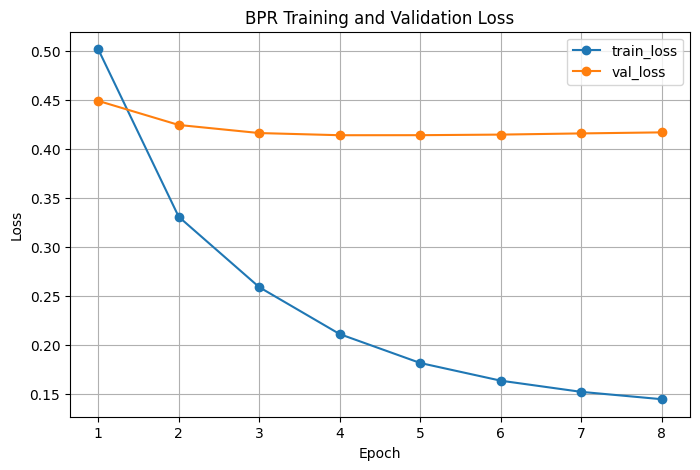

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="train_loss",
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="val_loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BPR Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

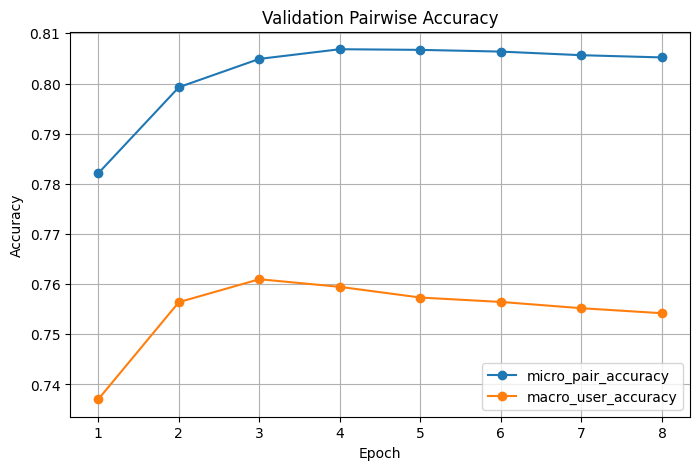

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_micro_pair_accuracy"],
    marker="o",
    label="micro_pair_accuracy",
)
plt.plot(
    history_df["epoch"],
    history_df["val_macro_user_accuracy"],
    marker="o",
    label="macro_user_accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Pairwise Accuracy")
plt.legend()
plt.grid(True)
plt.show()

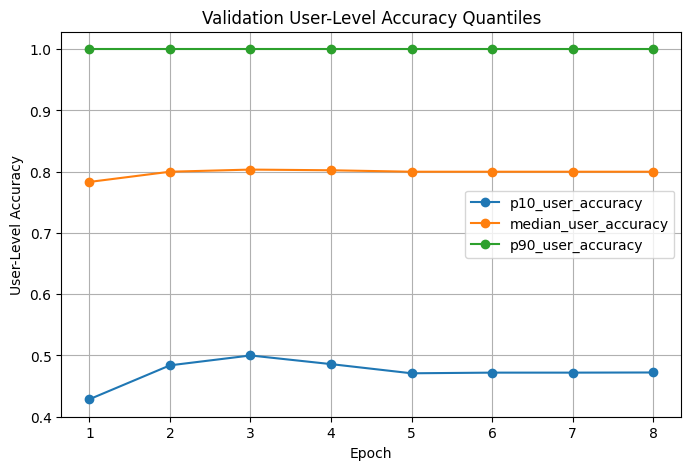

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_p10_user_accuracy"],
    marker="o",
    label="p10_user_accuracy",
)
plt.plot(
    history_df["epoch"],
    history_df["val_median_user_accuracy"],
    marker="o",
    label="median_user_accuracy",
)
plt.plot(
    history_df["epoch"],
    history_df["val_p90_user_accuracy"],
    marker="o",
    label="p90_user_accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("User-Level Accuracy")
plt.title("Validation User-Level Accuracy Quantiles")
plt.legend()
plt.grid(True)
plt.show()

# 17 Model Parameter Summary

We summarize the final model size. This helps document the complexity of the learned embedding model.

In [32]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

model_parameter_summary = pd.DataFrame([{
    "n_users": n_users,
    "n_items": n_items,
    "embedding_dim": training_config["embedding_dim"],
    "use_item_bias": training_config["use_item_bias"],
    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
}])

display(model_parameter_summary)

,n_users,n_items,embedding_dim,use_item_bias,total_parameters,trainable_parameters
0,4722,3250,64,True,513458,513458


# Save Results

In [33]:
step2_dir = "./results_step2"
os.makedirs(step2_dir, exist_ok=True)


def save_parquet_with_pickle_fallback(df, parquet_path):
    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception as error:
        pickle_path = parquet_path.replace(".parquet", ".pkl")
        df.to_pickle(pickle_path)
        print(
            f"Parquet save failed for {parquet_path}. "
            f"Saved pickle fallback to {pickle_path}. "
            f"Original error: {error}"
        )
        return pickle_path


# 1. Save BPR model checkpoint
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_users": n_users,
        "n_items": n_items,
        "training_config": training_config,
        "model_class": "BPRMatrixFactorization",
    },
    f"{step2_dir}/bpr_model.pt",
)


# 2. Save learned embeddings
user_embeddings = model.user_embeddings.weight.detach().cpu().numpy()
item_embeddings = model.item_embeddings.weight.detach().cpu().numpy()

np.save(f"{step2_dir}/user_embeddings.npy", user_embeddings)
np.save(f"{step2_dir}/item_embeddings.npy", item_embeddings)

if model.use_item_bias:
    item_bias = model.item_bias.weight.detach().cpu().numpy()
    np.save(f"{step2_dir}/item_bias.npy", item_bias)


# 3. Save index tables
user_index_table.to_csv(
    f"{step2_dir}/user_index_table.csv",
    index=False,
)

item_index_table.to_csv(
    f"{step2_dir}/item_index_table.csv",
    index=False,
)


# 4. Save indexed pairwise datasets for Step 4
save_parquet_with_pickle_fallback(
    train_pairs_idx,
    f"{step2_dir}/train_pairs_idx.parquet",
)

save_parquet_with_pickle_fallback(
    val_pairs_idx,
    f"{step2_dir}/validation_pairs_idx.parquet",
)

save_parquet_with_pickle_fallback(
    test_pairs_idx,
    f"{step2_dir}/test_pairs_idx.parquet",
)


# 5. Save training config
with open(f"{step2_dir}/bpr_training_config.json", "w") as f:
    json.dump(training_config, f, indent=2)


print("Saved minimal Step 2 results to:", step2_dir)

Saved minimal Step 2 results to: ./results_step2
